In [2]:
import pymysql as sql
import pandas as pd
from matplotlib import pyplot as plt 
from tabulate import tabulate as tb
import warnings
warnings.filterwarnings("ignore")

Summary
+---------+---------------+---------+
| product | sum(quantity) | revenue |
+---------+---------------+---------+
| Laptop  |     105.0     | 84000.0 |
|  Phone  |     245.0     | 73500.0 |
| Tablet  |     245.0     | 98000.0 |
+---------+---------------+---------+
+------------+----------+
|    date    | revenue  |
+------------+----------+
| 2025-04-01 | 108500.0 |
| 2025-04-02 | 70000.0  |
| 2025-04-03 | 77000.0  |
+------------+----------+





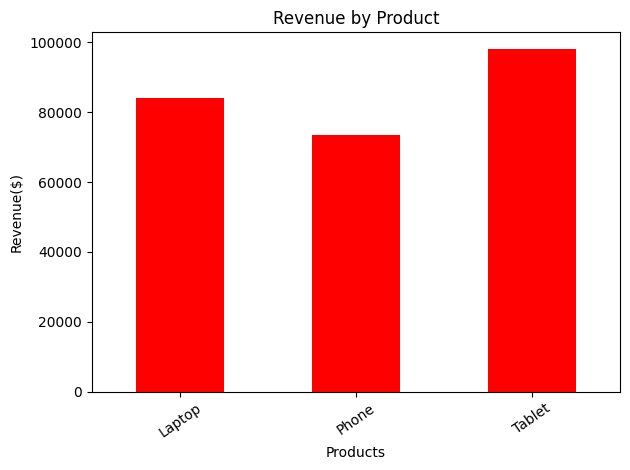

In [ ]:
conn = sql.connect(host=host,
                          user=user,
                          password=password,
                          database= database)
cursor = conn.cursor()

cursor.execute(""" 
                create table if not exists
               sales(
                    id int auto_increment primary key,
                    date date,
                    product varchar(50),
                    quantity int,
                    price decimal(10,2)
                    )
               """)

data = [
    ("2025-04-01", "Laptop", 2, 800.00),
    ("2025-04-01", "Phone", 5, 300.00),
    ("2025-04-02", "Tablet", 3, 400.00),
    ("2025-04-02", "Laptop", 1, 800.00),
    ("2025-04-03", "Phone", 2, 300.00),
    ("2025-04-03", "Tablet", 4, 400.00)
]

cursor.executemany("""insert into sales
                   (date,product,quantity,price)
                   values(%s,%s,%s,%s)""",
                   data)
conn.commit()

query = """ 
        select product,
                sum(quantity),
                sum(quantity * price) as revenue
                from sales
                group by product"""
df = pd.read_sql(query,conn)


q1 = """ 
    select date,
    sum(quantity * price)as revenue
    from sales
    group by date
    order by date"""
df1 = pd.read_sql(q1,conn)
print("Summary")
print(tb(df,headers='keys',tablefmt='pretty',showindex=False))
print(tb(df1, headers='keys',tablefmt='pretty',showindex=False))

print('\n'*2)
# Plot Chart
df.plot(kind='bar',x='product',y='revenue',legend=False,color='red')
plt.title('Revenue by Product')
plt.ylabel('Revenue($)')
plt.xlabel('Products')
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

conn.close()